Задание 1. Субдифференциал и негладкая оптимизация

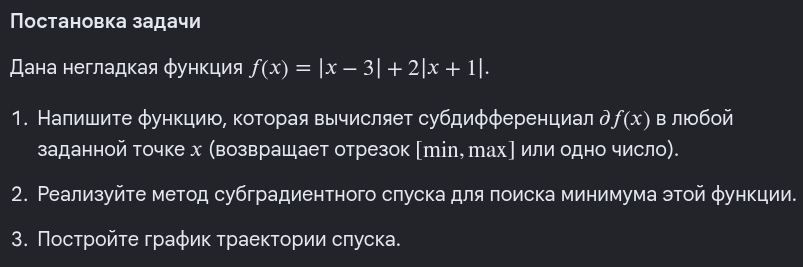

Финальная точка: -0.9493
Лучшая найденная точка: -0.9989
Минимальное значение функции: 4.0011


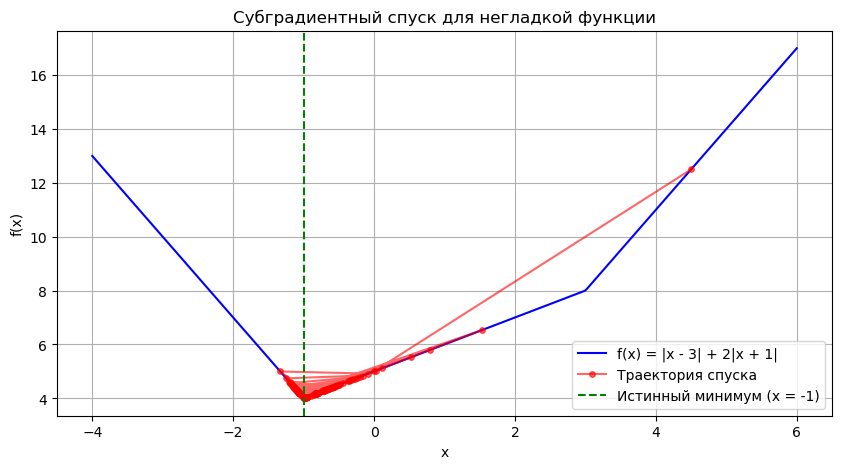

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def subdifferential_f(x):
    """
    Возвращает границы субдифференциала [g_min, g_max] в точке x.
    f(x) = |x - 3| + 2|x + 1|
    """
    # 1. Субдифференциал для |x - 3|
    if x > 3:
        sub_1 = np.array([1.0, 1.0])
    elif x < 3:
        sub_1 = np.array([-1.0, -1.0])
    else:
        sub_1 = np.array([-1.0, 1.0])

    # 2. Субдифференциал для 2*|x + 1|
    if x > -1:
        sub_2 = np.array([2.0, 2.0])
    elif x < -1:
        sub_2 = np.array([-2.0, -2.0])
    else:
        sub_2 = np.array([-2.0, 2.0])

    # Корректное поэлементное сложение массивов NumPy
    return sub_1 + sub_2


def subgradient_descent(x0, lr_0, steps=100):
    x = x0
    history = [x]
    for k in range(1, steps + 1):
        g_bounds = subdifferential_f(x)
        # Берем среднее значение из субдифференциала в качестве субградиента
        g = (g_bounds[0] + g_bounds[1]) / 2.0

        # Затухающий шаг важен, так как субградиент не стремится к нулю в минимуме
        lr = lr_0 / np.sqrt(k)
        x = x - lr * g
        history.append(x)
    return np.array(history)


# Запуск с увеличенным числом шагов для лучшей сходимости
x0 = 4.5
history = subgradient_descent(x0, lr_0=1.5, steps=200)
print(f"Финальная точка: {history[-1]:.4f}")

# Отрисовка графика
x_vals = np.linspace(-4, 6, 400)
y_vals = np.abs(x_vals - 3) + 2 * np.abs(x_vals + 1)
history_y = np.abs(history - 3) + 2 * np.abs(history + 1)
# Находим индекс точки с минимальным значением функции
best_idx = np.argmin(history_y)
print(f"Лучшая найденная точка: {history[best_idx]:.4f}")
print(f"Минимальное значение функции: {history_y[best_idx]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label="f(x) = |x - 3| + 2|x + 1|", color="blue")
plt.plot(history, history_y, "ro-", label="Траектория спуска", markersize=4, alpha=0.6)
plt.axvline(-1, color="green", linestyle="--", label="Истинный минимум (x = -1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Субградиентный спуск для негладкой функции")
plt.legend()
plt.grid(True)
plt.show()

Задание 2. Проверка условий ККТ для ограничений-равенств

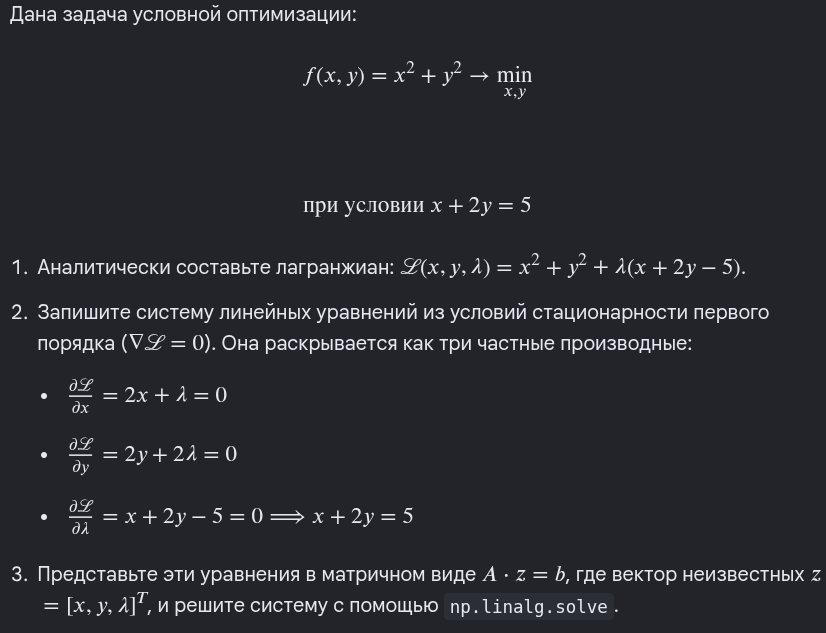

In [ ]:
import numpy as np

# Система уравнений ККТ имеет вид A * [x, y, lambda]^T = b
# 1-я строка: 2*x + 0*y + 1*lambda = 0
# 2-я строка: 0*x + 2*y + 2*lambda = 0
# 3-я строка: 1*x + 2*y + 0*lambda = 5

A = np.array(
    [
        [2.0, 0.0, 1.0],  # коэффициенты для dL/dx
        [0.0, 2.0, 2.0],  # коэффициенты для dL/dy
        [1.0, 2.0, 0.0],  # коэффициенты для dL/d_lambda
    ]
)

b = np.array([0.0, 0.0, 5.0])

# Решаем СЛАУ
solution = np.linalg.solve(A, b)

print(f"Оптимальное x: {solution[0]:.4f}")
print(f"Оптимальное y: {solution[1]:.4f}")
print(f"Множитель Лагранжа lambda: {solution[2]:.4f}")

Оптимальное x: 1.0000
Оптимальное y: 2.0000
Множитель Лагранжа lambda: -2.0000


Задание 3. Проекция на аффинное многообразие (Метод Лагранжа в матричном виде)

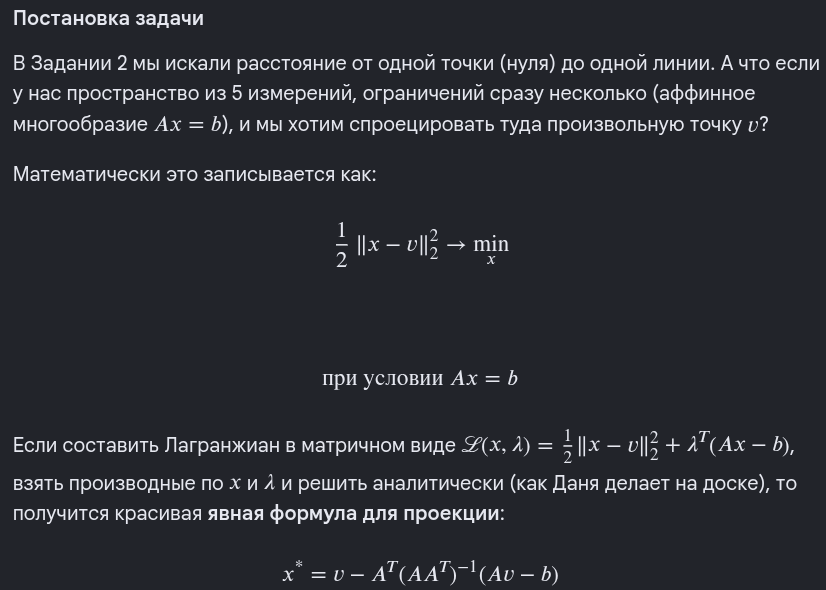

In [ ]:
import numpy as np

# 1. Генерируем случайные исходные данные для воспроизводимости
np.random.seed(42)
A = np.random.randn(2, 5)  # 2 ограничения (строки), 5 переменных (столбцов)
b = np.array([1.5, -0.5])  # вектор правых частей ограничений
v = np.random.randn(5)  # случайная точка в R^5, которую мы хотим спроецировать


def project_on_affine(A, b, v):
    """
    Реализует явную матричную формулу: x* = v - A^T * (A * A^T)^(-1) * (A * v - b)
    """
    # Вычисляем матрицу (A * A^T)
    AA_t = A @ A.T

    # Вычисляем вектор в скобках: (A * v - b)
    bracket = A @ v - b

    # Вместо явного вычисления обратной матрицы inv(AA_t) * bracket,
    # эффективнее и стабильнее решить СЛАУ: (A A^T) * lam = bracket
    lam = np.linalg.solve(AA_t, bracket)

    # Считаем финальный вектор x*
    x_opt = v - A.T @ lam

    return x_opt


# 2. Запуск функции
x_star = project_on_affine(A, b, v)

# 3. Проверка результатов
print("Точка x^*:          ", x_star)
print("Вектор Ax^*:        ", A @ x_star)
print("Вектор b:           ", b)
print("Проверка (Ax^* == b):", np.allclose(A @ x_star, b))

Точка x^*:           [ 0.15821673 -0.26185273  1.31959358  0.05462917 -1.91036805]
Вектор Ax^*:         [ 1.5 -0.5]
Вектор b:            [ 1.5 -0.5]
Проверка (Ax^* == b): True
